In [24]:
import seaborn as sns

BASE_FONTSIZE = 22
sns.set_theme(
    style="ticks",
    rc={
        "font.size": BASE_FONTSIZE,
        "axes.titlesize": BASE_FONTSIZE,
        "axes.labelsize": BASE_FONTSIZE,
        "xtick.labelsize": BASE_FONTSIZE * 0.85,
        "ytick.labelsize": BASE_FONTSIZE * 0.85,
        "legend.title_fontsize": BASE_FONTSIZE * 0.9,
        "legend.fontsize": BASE_FONTSIZE * 0.9,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "hatch.linewidth": 1.5,
        "hatch.color": "#333333",
    },
)


def apply_hatches(g, hatch_map):
    """Apply hatches by matching legend colors to bars."""
    # Build color -> hatch from legend
    color_to_hatch = {}
    for text, handle in zip(g._legend.get_texts(), g._legend.legend_handles):
        hatch = hatch_map.get(text.get_text(), None)
        if hatch:
            fc = handle.get_facecolor()
            color_to_hatch[tuple(fc)] = hatch

    # Apply to all bars
    for ax in g.axes.flat:
        for bar in ax.patches:
            hatch = color_to_hatch.get(tuple(bar.get_facecolor()))
            if hatch:
                bar.set_hatch(hatch)
                bar.set_edgecolor("#333333")

## Figures 1-3. Error terms

First run the following scripts:

1. Run fine-tuning with checkpointing.
2. Generate covariances for each ckpt: [scripts/vision/generate_error_terms.py](../scripts/vision/generate_error_terms.py)
3. Generate error terms: [scripts/vision/generate_error_terms.py](../scripts/vision/generate_error_terms.py)

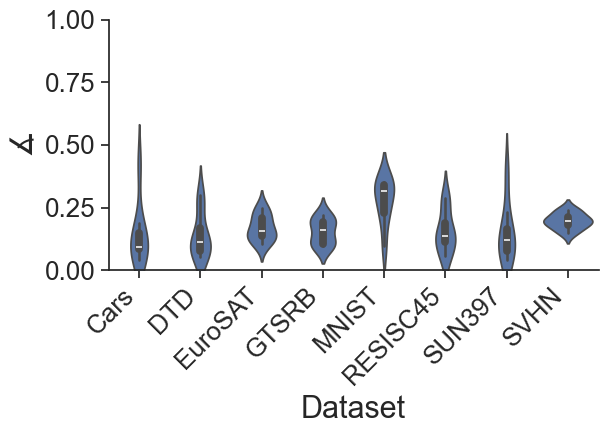

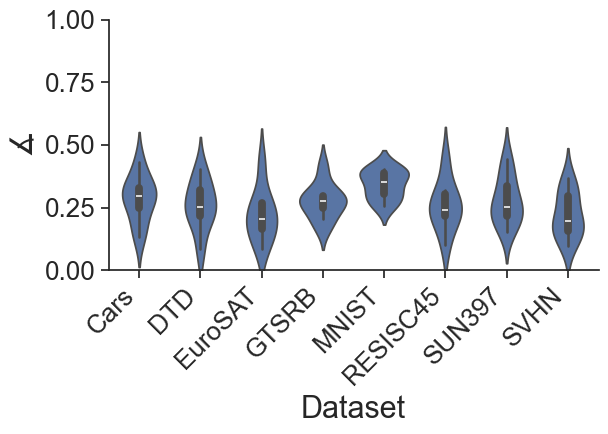

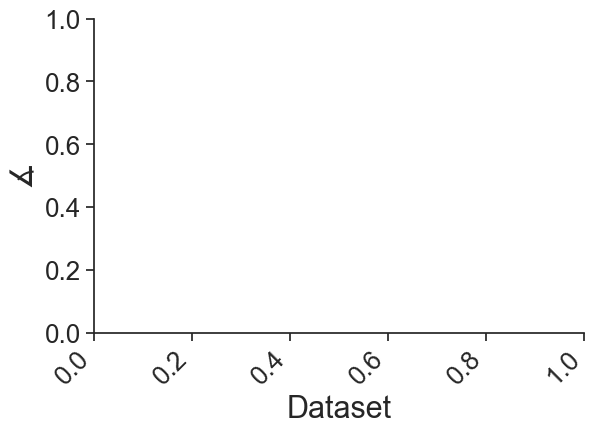

In [23]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

model = "ViT-B-16"
results_dir = f"../results-analysis/{model}"

for type in ["cross", "corr", "drift"]:

    # Compute angular distance: https://en.wikipedia.org/wiki/Cosine_similarity
    df = pd.read_csv(os.path.join(results_dir, "error_terms.csv"))
    df["angular_distance"] = np.arccos(df["cosine_similarity"].clip(-1.0, 1.0)) / np.pi
    df = df[df["type"] == type]

    # Make violin plot
    plt.figure()
    sns.violinplot(data=df, x="dataset", y="angular_distance")
    plt.ylim(0, 1)  # Set y-axis range from 0 to 1
    plt.ylabel(r"$\measuredangle$")
    plt.xlabel("Dataset")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(
        os.path.join(results_dir, f"error_{type}_term.pdf"), bbox_inches="tight"
    )
    plt.show()
    plt.close()

## Figure 4. Performance on ViT/T5

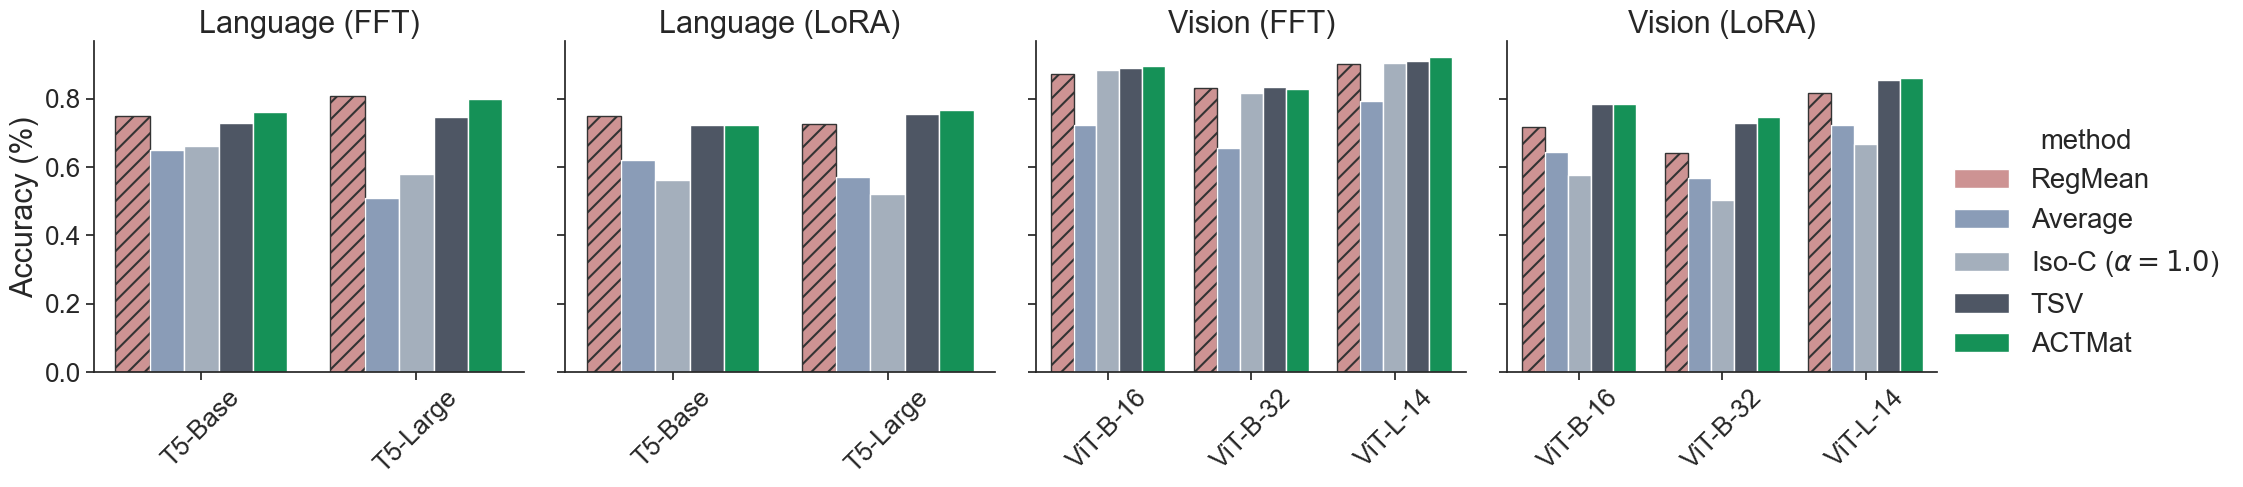

In [25]:
import os
import json
import numpy as np
import pandas as pd
import seaborn as sns

methods = [
    "zeroshot",
    "experts",
    "regmean",
    "regmean-w",
    "fisher",
    "sum04",
    "mean",
    "isoc",
    "isoc2",
    "isoc3",
    "tsv",
    "ace",
    "actmat",
]
models = ["ViT-B-16", "ViT-B-32", "ViT-L-14", "T5-Base", "T5-Large"]

method_to_method = {
    "zeroshot": "Zero-shot",
    "experts": "Experts",
    "regmean": "RegMean",
    "regmean-w": "RegMean-W",
    "fisher": "Fisher",
    "sum04": "TA ($\\alpha=0.4$)",
    "mean": "Average",
    "isoc": "Iso-C ($\\alpha=1.0$)",
    "isoc2": "Iso-C ($\\alpha=2.0$)",
    "isoc3": "Iso-C ($\\alpha=3.0$)",
    "tsv": "TSV",
    "actmat": "ACTMat",
    "ace": "ACE",
}

method_to_color = {
    # Base/Reference (Muted Gray)
    "Zero-shot": "#B0B0B0",
    # Group 1: Data-Dependent Methods (Muted Reds/Terracottas)
    "RegMean": "#D68A8A",
    "RegMean-W": "#B0E0E6",
    "Fisher": "#BA6B6B",
    "DiFisher": "#9DB7E5",
    "DiFisher-v2": "#9DB7E5",
    # Group 2: Merging/Ensembling Baselines (Muted Blues)
    "Experts": "#A3B7D9",
    "Average": "#829ABF",
    "TA ($\\alpha=0.4$)": "#637B9D",
    # Group 3: Task Vectors, Iso-C, and KNOTS Variants (Muted Slates)
    "Iso-C ($\\alpha=1.0$)": "#A0AEC0",  # Lighter slate to complete the family progression
    "Iso-C ($\\alpha=2.0$)": "#A0AEC0",  # Lighter slate to complete the family progression
    "Iso-C ($\\alpha=3.0$)": "#A0AEC0",  # Lighter slate to complete the family progression
    "KNOTS-Iso-C": "#718096",  # (User specified)
    "TSV": "#4A5568",  # (User specified)
    "KNOTS-TSV": "#4A5568",  # (User specified) - Note: Use "#2D3748" if you need it darker/distinct
    # Group 4: ActMat (Muted Gold/Mustard)
    "ACE": "#6EE7B7",  # lighter green
    "ACTMat": "#00A658",
}

method_to_hatch = {
    "TA": "//",
    "RegMean": "//",
    "RegMean-W": "//",
    "Fisher": "\\",
}

method_to_linestyle = {
    "Experts": "-",
    "Zero-shot": ".",
}

model_to_group = {
    "T5-Base::fft": "Language (FFT)",
    "T5-Large::fft": "Language (FFT)",
    "ViT-B-16::fft": "Vision (FFT)",
    "ViT-B-32::fft": "Vision (FFT)",
    "ViT-L-14::fft": "Vision (FFT)",
    # LoRA
    "T5-Base::lora": "Language (LoRA)",
    "T5-Large::lora": "Language (LoRA)",
    "ViT-B-16::lora": "Vision (LoRA)",
    "ViT-B-32::lora": "Vision (LoRA)",
    "ViT-L-14::lora": "Vision (LoRA)",
}

rows = []
for model in models:
    for method in methods:

        fft_filename = f"../results/{model}-{method}/metrics.json"
        lora_filename = f"../results/{model}-{method}/lora_metrics.json"

        for finetuning_mode, ft_filename in [
            ("fft", fft_filename),
            ("lora", lora_filename),
        ]:
            if not os.path.exists(ft_filename):
                continue
            with open(ft_filename, "r") as f:
                metrics = json.load(f)
                scores = [t["metrics"]["primary_score"] for t in metrics["tasks"]]
                avg_score = np.mean(scores)
                rows.append(
                    {
                        "model": model,
                        "finetuning_mode": finetuning_mode,
                        "method": method,
                        "acc": avg_score,
                    }
                )


df = pd.DataFrame(rows)
df["group"] = (df["model"] + "::" + df["finetuning_mode"]).map(
    lambda x: model_to_group[x]
)
df["method"] = df["method"].map(lambda x: method_to_method[x])
# display(df)
g = sns.catplot(
    data=df,
    x="model",
    hue="method",
    y="acc",
    col="group",
    col_order=["Language (FFT)", "Language (LoRA)", "Vision (FFT)", "Vision (LoRA)"],
    kind="bar",
    palette=method_to_color,
    sharex=False,
)
# Formatting.
g.set_axis_labels("", "Accuracy (%)")
g.set_xticklabels(rotation=45)
g.set_titles("{col_name}", fontsize=BASE_FONTSIZE)

# # Legend.
# g._legend.remove()
# g.fig.legend(
#     *g.axes.flat[0].get_legend_handles_labels(),
#     loc="lower center",
#     ncol=4,
#     bbox_to_anchor=(0.5, -0.1),
#     title="",
#     frameon=False,
# )
# g.fig.subplots_adjust(bottom=0.35)
apply_hatches(g, method_to_hatch)
# apply_linestyles(g, method_to_linestyle)

In [26]:
# Display all methods
# filter (fft only)
dfp = df[df["finetuning_mode"] == "fft"]
dfp = dfp.pivot(index="method", columns="model", values="acc")
dfp = (dfp * 100).round(1)
dfp.sort_values(by="ViT-B-16")

model,T5-Base,T5-Large,ViT-B-16,ViT-B-32,ViT-L-14
method,,,,,
Average,64.9,51.0,72.2,65.4,79.3
RegMean,74.9,80.8,87.2,83.0,90.1
Iso-C ($\alpha=1.0$),66.1,57.8,88.4,81.6,90.5
TSV,72.9,74.6,88.8,83.3,91.1
ACTMat,76.1,79.8,89.5,82.9,92.2


In [27]:
# Display all methods
# filter (lora only)
dfp = df[df["finetuning_mode"] == "lora"]
dfp = dfp.pivot(index="method", columns="model", values="acc")
dfp = (dfp * 100).round(1)
dfp.sort_values(by="ViT-B-16")

model,T5-Base,T5-Large,ViT-B-16,ViT-B-32,ViT-L-14
method,,,,,
Iso-C ($\alpha=1.0$),56.3,52.0,57.5,50.4,66.8
Average,62.2,57.1,64.3,56.8,72.4
RegMean,74.9,72.7,71.8,64.2,81.6
TSV,72.2,75.4,78.3,73.0,85.4
ACTMat,72.2,76.7,78.6,74.6,86.1


In [7]:
# Display only RegMean and RegMean-W
dfp = df.pivot(index="method", columns="model", values="acc")
dfp = (dfp * 100).round(1)
dfp = dfp[dfp.index.isin(["RegMean", "RegMean-W"])]
dfp.sort_values(by="ViT-B-16")

model,T5-Base,T5-Large,ViT-B-16,ViT-B-32,ViT-L-14
method,,,,,
RegMean,74.9,80.8,87.2,83.0,90.1


## Figure 5. Correlation between activations and gradients

First run this script to generate the correlations: [scripts/vision/correlation.py](../scripts/vision/correlation.py)